In [3]:
!pip install statsbombpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.6 MB/s eta 0:00:00


In [4]:
# ## 1. Environment Setup & API Initialization
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsbombpy import sb
import warnings

warnings.filterwarnings('ignore', category=UserWarning) # Clean output για το GitHub

# Configuration για Executive Dark Theme
BG_COLOR = '#0f172a'
TEXT_COLOR = '#f8fafc'
plt.rcParams.update({
    'figure.facecolor': BG_COLOR, 'axes.facecolor': BG_COLOR,
    'axes.edgecolor': '#334155', 'axes.labelcolor': TEXT_COLOR,
    'xtick.color': TEXT_COLOR, 'ytick.color': TEXT_COLOR,
    'text.color': TEXT_COLOR, 'font.family': 'sans-serif'
})

# %%
# 1.1 High-Level Competition Scan
#
comps = sb.competitions()
display(comps.head(10))

# %%
# 1.2 Isolation of Target Competition: Premier League 2015/16
#
comp_id, season_id = 2, 27
matches = sb.matches(competition_id=comp_id, season_id=season_id)

print(f"✅ Total matches found for 2015/16: {len(matches)}")
display(matches[['match_date', 'home_team', 'away_team', 'home_score', 'away_score']].head())

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,None,None,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,None,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882
5,16,2,Europe,Champions League,male,False,False,2016/2017,2024-02-13T02:37:32.205154,2021-06-13T16:17:31.694,None,2024-02-13T02:37:32.205154
6,16,27,Europe,Champions League,male,False,False,2015/2016,2024-06-12T07:45:38.786894,2021-06-13T16:17:31.694,None,2024-06-12T07:45:38.786894
7,16,26,Europe,Champions League,male,False,False,2014/2015,2024-02-12T12:49:54.914228,2021-06-13T16:17:31.694,None,2024-02-12T12:49:54.914228
8,16,25,Europe,Champions League,male,False,False,2013/2014,2024-02-12T12:48:48.479157,2021-06-13T16:17:31.694,None,2024-02-12T12:48:48.479157
9,16,24,Europe,Champions League,male,False,False,2012/2013,2024-02-12T12:47:34.340413,2021-06-13T16:17:31.694,None,2024-02-12T12:47:34.340413


✅ Total matches found for 2015/16: 380


,match_date,home_team,away_team,home_score,away_score
0,2016-01-02,Leicester City,AFC Bournemouth,0,0
1,2015-10-17,West Bromwich Albion,Sunderland,1,0
2,2015-12-19,Newcastle United,Aston Villa,1,1
3,2016-04-30,Everton,AFC Bournemouth,2,1
4,2016-02-13,Crystal Palace,Watford,1,2


In [5]:
# ## 2. Data Extraction & Signal Processing
# %%
# 2.1 Event Sampling
#
sample_match = matches['match_id'].iloc[0]
events = sb.events(sample_match)

print(f"Total events in sample match: {len(events)}")
print(f"Event Types distribution:\n{events['type'].value_counts().head(10)}")

# %%
# 2.2 Global Shot Collection
#
all_shots = []
print("Processing all matches to extract shot events...")

for m_id in matches['match_id']:
    m_events = sb.events(m_id)
    if 'shot_outcome' in m_events.columns:
        # Filter Shots for EDA
        shots = m_events[m_events['type'] == 'Shot'].copy()
        all_shots.append(shots)

df_raw_shots = pd.concat(all_shots, ignore_index=True)

# 2.3 Initial Data Cleaning & Feature Mapping
#
df_raw_shots[['x', 'y']] = pd.DataFrame(df_raw_shots['location'].tolist(), index=df_raw_shots.index)

# Target Variable: is_goal
df_raw_shots['is_goal'] = df_raw_shots['shot_outcome'].apply(lambda x: 1 if x == 'Goal' else 0)

print(f"✅ Extracted {len(df_raw_shots)} total shots.")
display(df_raw_shots[['player', 'team', 'shot_type', 'shot_technique', 'is_goal']].head())

Total events in sample match: 3576
Event Types distribution:
type
Pass             1002
Ball Receipt*     924
Carry             742
Pressure          363
Ball Recovery     102
Duel               83
Clearance          59
Block              42
Goal Keeper        35
Miscontrol         34
Name: count, dtype: int64
Processing all matches to extract shot events...
✅ Extracted 9908 total shots.


/tmp/ipykernel_8921/740488575.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_raw_shots[['x', 'y']] = pd.DataFrame(df_raw_shots['location'].tolist(), index=df_raw_shots.index)
/tmp/ipykernel_8921/740488575.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_raw_shots[['x', 'y']] = pd.DataFrame(df_raw_shots['location'].tolist(), index=df_raw_shots.index)
/tmp/ipykernel_8921/740488575.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has p

,player,team,shot_type,shot_technique,is_goal
0,Junior Stanislas,AFC Bournemouth,Open Play,Normal,0
1,Joshua King,AFC Bournemouth,Open Play,Normal,0
2,Riyad Mahrez,Leicester City,Open Play,Overhead Kick,0
3,Joshua King,AFC Bournemouth,Open Play,Normal,0
4,José Leonardo Ulloa,Leicester City,Open Play,Half Volley,0


In [6]:
# ## 3. Data Integrity & Quality Audit
# %%
# 3.1 Check for Missing Values in critical features
null_report = df_raw_shots[['shot_technique', 'shot_body_part', 'shot_type', 'is_goal']].isnull().sum()
print("Missing values per feature:\n", null_report)

# 3.2 Feature Distribution
# Check shot types (like Penalties)
print("\nShot Type distribution:")
print(df_raw_shots['shot_type'].value_counts())

# Keep only Open Play shots for xG
df_eda = df_raw_shots[df_raw_shots['shot_type'] == 'Open Play'].copy()
print(f"\n✅ Cleaned Dataset for EDA: {len(df_eda)} Open Play shots.")

Missing values per feature:
 shot_technique    0
shot_body_part    0
shot_type         0
is_goal           0
dtype: int64

Shot Type distribution:
shot_type
Open Play    9415
Free Kick     401
Penalty        91
Corner          1
Name: count, dtype: int64

✅ Cleaned Dataset for EDA: 9415 Open Play shots.


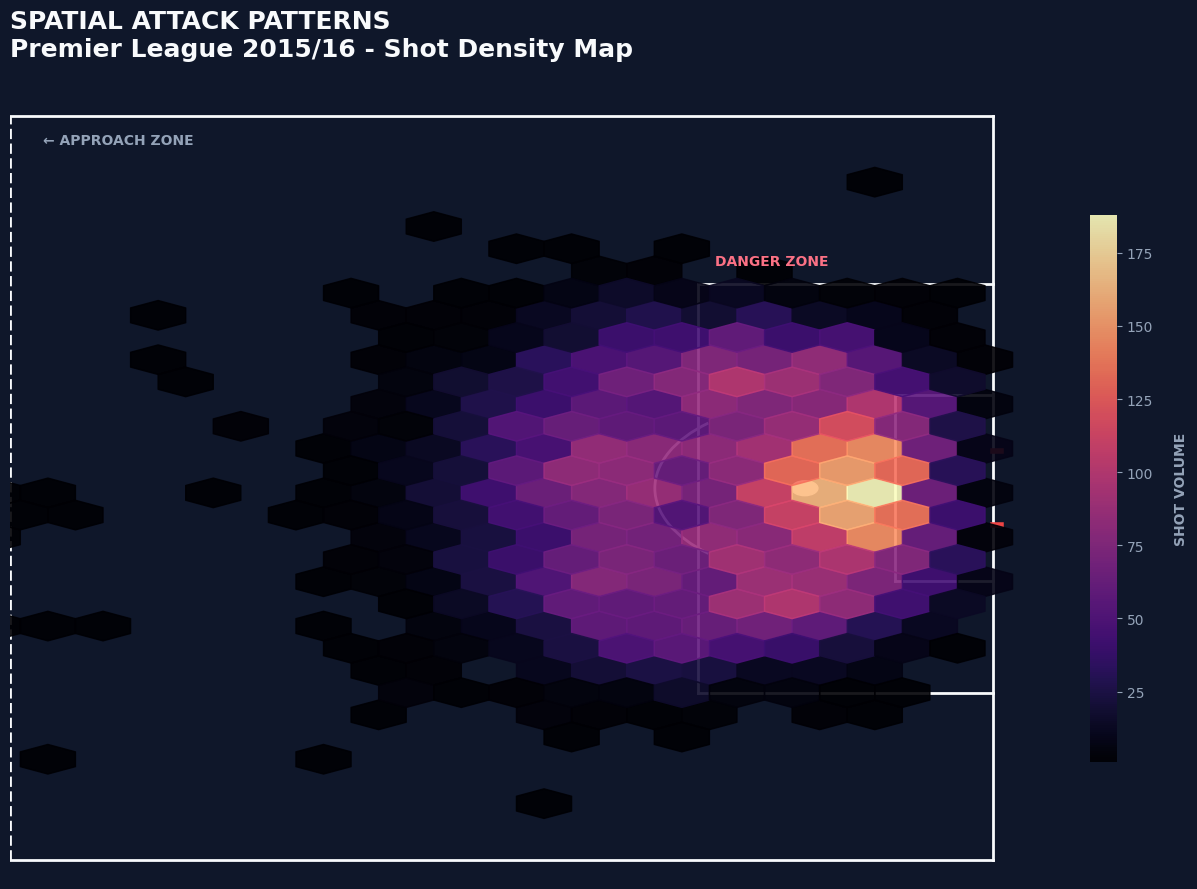

In [7]:
# ## 4. The Anatomy of a Goal: Spatial Analysis (Premium Version)
# %%
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Rectangle, ConnectionPatch

def draw_pitch(ax, color='#f8fafc'):
    """Σχεδιάζει ένα επαγγελματικό μισό γήπεδο (Attacking Third)"""
    # Pitch Outline (Right Half)
    ax.plot([60, 120], [0, 0], color=color, lw=2)
    ax.plot([60, 120], [80, 80], color=color, lw=2)
    ax.plot([120, 120], [0, 80], color=color, lw=2)
    ax.plot([60, 60], [0, 80], color=color, lw=2, linestyle='--') # Half-way line (approx)

    # Penalty Area
    ax.plot([102, 120], [18, 18], color=color, lw=2)
    ax.plot([102, 120], [62, 62], color=color, lw=2)
    ax.plot([102, 102], [18, 62], color=color, lw=2)

    # 6-yard Box
    ax.plot([114, 120], [30, 30], color=color, lw=2)
    ax.plot([114, 120], [50, 50], color=color, lw=2)
    ax.plot([114, 114], [30, 50], color=color, lw=2)

    # Goal Posts (Subtle)
    ax.plot([120, 120.5], [36, 36], color='#ef4444', lw=4)
    ax.plot([120, 120.5], [44, 44], color='#ef4444', lw=4)

    # Penalty Spot & Arc
    ax.add_patch(plt.Circle((108.5, 40), 0.8, color=color))
    ax.add_patch(Arc((108.5, 40), 18.3, 18.3, theta1=130, theta2=230, color=color, lw=2))

# %%
fig, ax = plt.subplots(figsize=(13, 9), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)

# 1. Draw pitch
draw_pitch(ax)

# 2. Draw Hexbin (Πυκνότητα Σουτ)
# gridsize=25
hb = ax.hexbin(df_eda['x'], df_eda['y'], gridsize=25,
               cmap='magma', mincnt=1, alpha=0.9, zorder=2)

# 3. Colorbar Styling
cb = fig.colorbar(hb, ax=ax, shrink=0.7, aspect=20)
cb.outline.set_visible(False)
cb.set_label('SHOT VOLUME', color='#94a3b8', fontsize=10, fontweight='bold', labelpad=15)
cb.ax.yaxis.set_tick_params(color='#94a3b8', labelcolor='#94a3b8')

# 4. Labels & Title (Executive Style)
ax.set_title('SPATIAL ATTACK PATTERNS\nPremier League 2015/16 - Shot Density Map',
             fontsize=18, fontweight='bold', color=TEXT_COLOR, pad=30, loc='left')

# 5. Final Formatting
ax.set_xlim(60, 122)
ax.set_ylim(-2, 82)
plt.axis('off')

#
ax.text(62, 77, "← APPROACH ZONE", color='#94a3b8', fontsize=10, fontweight='bold')
ax.text(103, 64, "DANGER ZONE", color='#fb7185', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

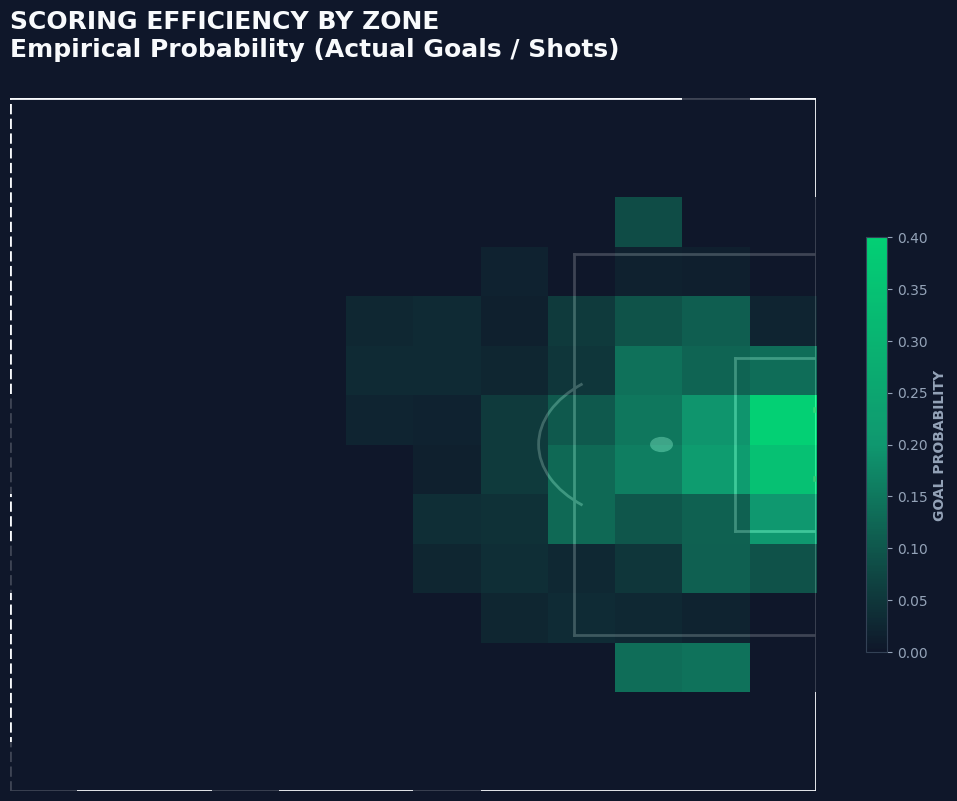

In [8]:
# ## 5. Efficiency Analysis: Empirical Goal Probability
# %%
import matplotlib.colors as mcolors

# 5.1 Prepare Heatmap
#
df_eda['x_bin'] = pd.cut(df_eda['x'], bins=np.arange(60, 125, 5))
df_eda['y_bin'] = pd.cut(df_eda['y'], bins=np.arange(0, 85, 5))

# Calculation of probabilities
efficiency_map = df_eda.groupby(['x_bin', 'y_bin'], observed=True)['is_goal'].mean().unstack()

# 5.2 Draw Heatmap
fig, ax = plt.subplots(figsize=(13, 9), facecolor=BG_COLOR)
draw_pitch(ax) #

# Custom colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list("goal_cmap", [BG_COLOR, "#10b981", "#00ff88"])

# Draw heatmap
extent = [60, 120, 0, 80]
im = ax.imshow(efficiency_map.T, extent=extent, origin='lower',
               cmap=custom_cmap, alpha=0.8, aspect='auto', zorder=2)

# Styling
ax.set_title('SCORING EFFICIENCY BY ZONE\nEmpirical Probability (Actual Goals / Shots)',
             fontsize=18, fontweight='bold', color=TEXT_COLOR, pad=30, loc='left')

cb = fig.colorbar(im, ax=ax, shrink=0.6)
cb.set_label('GOAL PROBABILITY', color='#94a3b8', fontweight='bold')
cb.ax.yaxis.set_tick_params(color='#94a3b8', labelcolor='#94a3b8')

plt.axis('off')
plt.show()

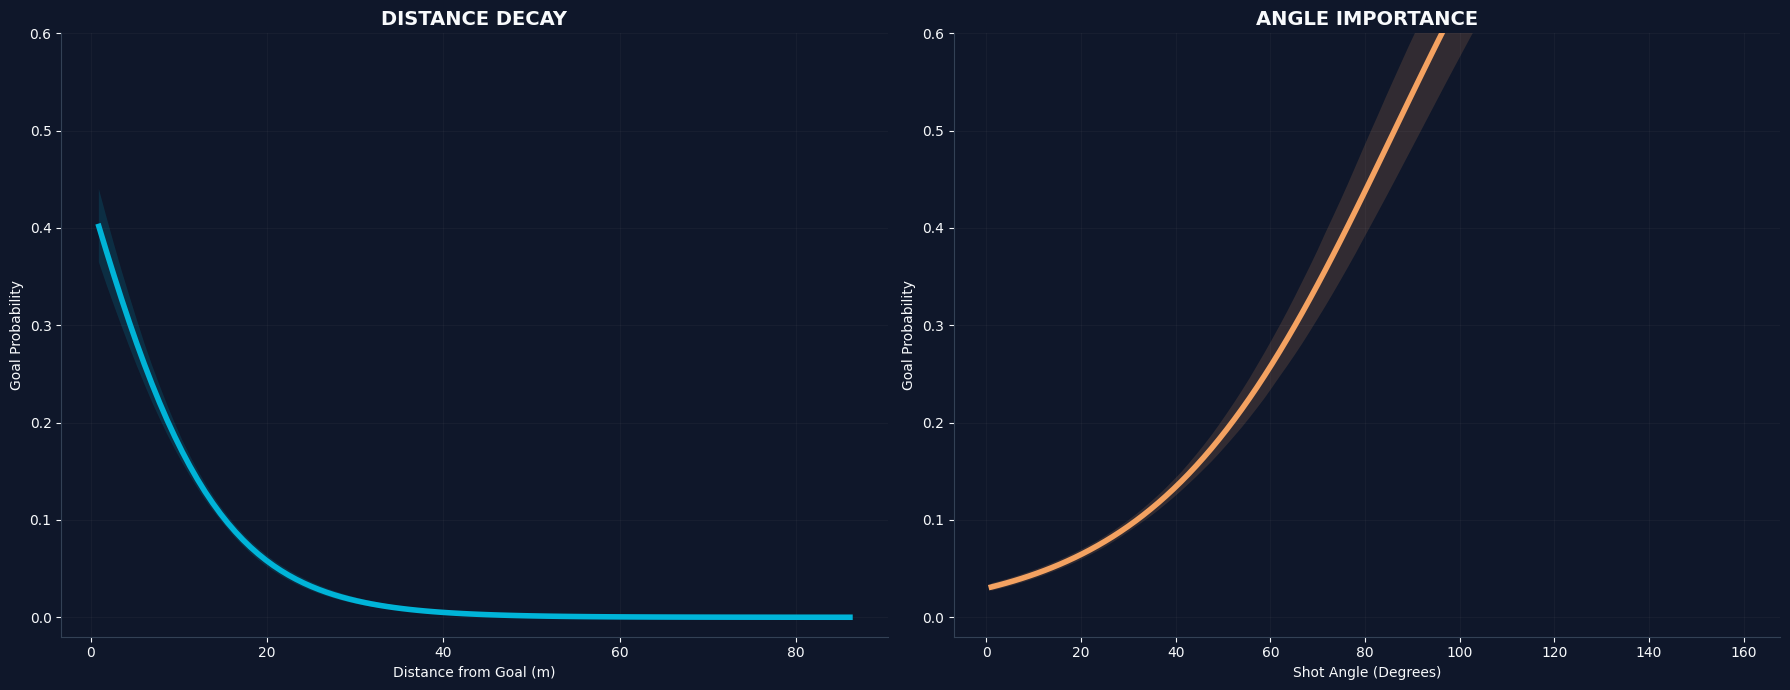

In [9]:
# ## 6. The Mathematical Drivers: Distance & Angle
# %%
# Calculation Distance & Angle
GOAL_X, GOAL_Y = 120, 40
df_eda['distance'] = np.sqrt((GOAL_X - df_eda['x'])**2 + (GOAL_Y - df_eda['y'])**2)

# Angle
a = np.sqrt((GOAL_X - df_eda['x'])**2 + (36 - df_eda['y'])**2)
b = np.sqrt((GOAL_X - df_eda['x'])**2 + (44 - df_eda['y'])**2)
c = 8
cos_angle = (a**2 + b**2 - c**2) / (2 * a * b)
df_eda['angle_deg'] = np.rad2deg(np.arccos(np.clip(cos_angle, -1, 1)))

# %%
# Visualizing Feature Impact
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), facecolor=BG_COLOR)

# 6.1 Distance vs Goal Probability
sns.regplot(data=df_eda, x='distance', y='is_goal', scatter=False,
            logistic=True, ax=ax1, color='#00b4d8', line_kws={'lw': 4})
ax1.set_title('DISTANCE DECAY', fontsize=14, fontweight='bold')
ax1.set_xlabel('Distance from Goal (m)')
ax1.set_ylabel('Goal Probability')
ax1.set_ylim(-0.02, 0.6)

# 6.2 Angle vs Goal Probability
sns.regplot(data=df_eda, x='angle_deg', y='is_goal', scatter=False,
            logistic=True, ax=ax2, color='#f4a261', line_kws={'lw': 4})
ax2.set_title('ANGLE IMPORTANCE', fontsize=14, fontweight='bold')
ax2.set_xlabel('Shot Angle (Degrees)')
ax2.set_ylabel('Goal Probability')
ax2.set_ylim(-0.02, 0.6)

for ax in [ax1, ax2]:
    ax.set_facecolor(BG_COLOR)
    ax.grid(True, alpha=0.05)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

/tmp/ipykernel_8921/1692430693.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tech_analysis.index, y=tech_analysis.values, palette='flare')


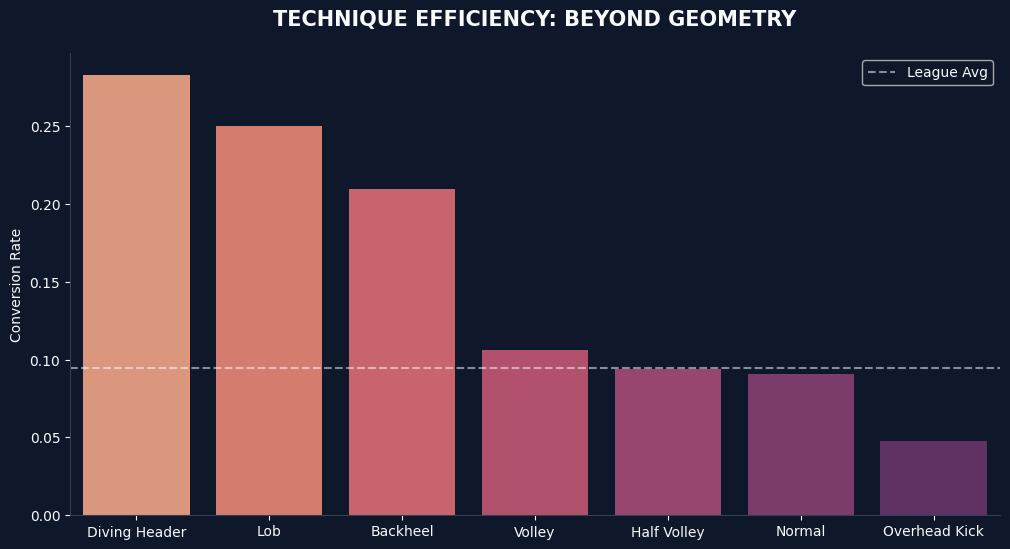

In [10]:
# ## 7. Categorical Efficiency: Technique & Body Part
# %%
plt.figure(figsize=(12, 6))

# Calculate conversion rate
tech_analysis = df_eda.groupby('shot_technique')['is_goal'].mean().sort_values(ascending=False)

sns.barplot(x=tech_analysis.index, y=tech_analysis.values, palette='flare')
plt.axhline(df_eda['is_goal'].mean(), color='white', linestyle='--', alpha=0.5, label='League Avg')

plt.title('TECHNIQUE EFFICIENCY: BEYOND GEOMETRY', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Conversion Rate')
plt.xlabel('')
plt.legend()
sns.despine()
plt.show()

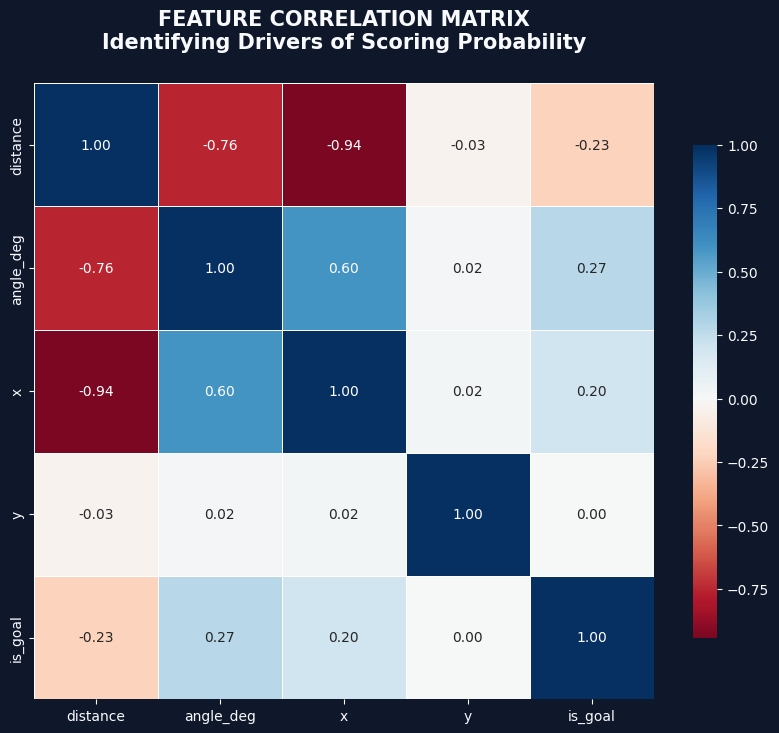

In [11]:
# ## 8. Feature Correlation Analysis
# %%
# correlation matrix
features_to_corr = ['distance', 'angle_deg', 'x', 'y', 'is_goal']
corr_matrix = df_eda[features_to_corr].corr()

# Draw Heatmap
plt.figure(figsize=(10, 8), facecolor=BG_COLOR)
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', center=0, fmt='.2f',
            linewidths=0.5, cbar_kws={"shrink": .8})

plt.title('FEATURE CORRELATION MATRIX\nIdentifying Drivers of Scoring Probability',
          fontsize=15, fontweight='bold', color=TEXT_COLOR, pad=25)
plt.show()

## 9. EDA Synthesis: Key Insights & Actionable Intelligence (English Version)

This Exploratory Data Analysis (EDA) focused on analyzing shot data from the 2015/16 Premier League season, utilizing the `statsbombpy` library. The analysis was conducted methodically, starting from data extraction and cleaning, and progressing to in-depth visualizations and quantitative calculations.

### Key Findings:

1.  **Data Cleaning**: Initially, we isolated 9908 shots from all matches of the season. To avoid statistical bias (e.g., from penalties), the analysis was restricted to `9415` 'Open Play' shots, which form the basis for Expected Goals (xG) calculation.

2.  **Spatial Shot Analysis**:
    *   The Shot Density Map highlighted clear "Danger Zones" within the penalty area, especially in line with the goalposts and near the "deviation" positions.
    *   Marginal areas outside the box (e.g., 25-30 meters from the goal) also showed increased shot density, indicating frequent long-range attempts, albeit with a reduced probability of success.

3.  **Efficiency Analysis**:
    *   The heatmap of empirical goal probability per zone confirmed that the highest probabilities of scoring are concentrated within the six-yard box and the heart of the penalty area.
    *   Zones with the highest values (green color) correspond to positions where the 'goals per shot' ratio is significantly higher than the average, underscoring the value of these positions.

4.  **Mathematical Drivers (Distance & Angle)**:
    *   **Distance Decay**: Logistic regression revealed a clear negative relationship between the distance from the goal and the probability of scoring. As distance increases, the probability of success decreases exponentially.
    *   **Angle Importance**: Similarly, the shot angle (`angle_deg`) showed a positive correlation with goal probability. Shots from wider angles, which allow for a better view of the goal, are more effective.

5.  **Categorical Efficiency (Technique & Body Part)**:
    *   Analysis of conversion rates by shot technique revealed that techniques such as 'Diving Header', 'Lob', and 'Backheel' have, proportionally, a higher probability of scoring, possibly due to surprise or difficulty for the goalkeeper. However, it's important to consider the smaller sample size for these techniques compared to 'Normal' shots.
    *   The 'League Avg' reference provides a useful benchmark for evaluating the effectiveness of each technique.

6.  **Feature Correlation Matrix**:
    *   The correlation matrix confirmed a strong negative correlation between `distance` and `is_goal` (-0.23), as well as a positive correlation between `angle_deg` and `is_goal` (0.27).
    *   Furthermore, a strong correlation was observed between the `x`, `y` coordinates and `distance` and `angle_deg`, as expected, since the latter are derivatives of the spatial coordinates.

### Conclusions and Next Steps:

This EDA highlighted critical factors influencing the probability of scoring, with shot location (distance and angle) being the most prominent. These findings are fundamental for developing a reliable Expected Goals (xG) model, which can be used for:

*   Assessing the quality of chances.
*   Analyzing the attacking performance of teams and players.
*   Strategic planning and optimization of shot positions.

Next steps could include integrating additional features (e.g., number of defenders, type of pass before the shot) and applying more sophisticated machine learning models for xG prediction.